# Laboratory Day 3: Filter in spatial domain

## 1. Averaging filter
**Exercise 1.1 (5 points)**:
Apply averaging filters to image '**dog_gray.png**' and visualize the filtered image.

- use kernel size 3*3.

- use kernel size 5*5

- Which kernel has stronger blurring effects?

Please use OpenCV filter2D() function.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
# please do not use other library to solve the exercises in this laboratory.

In [8]:
!git clone https://github.com/Ambos14/ComputerVision26.git

Cloning into 'ComputerVision26'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 44 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 4.31 MiB | 20.72 MiB/s, done.
Resolving deltas: 100% (7/7), done.


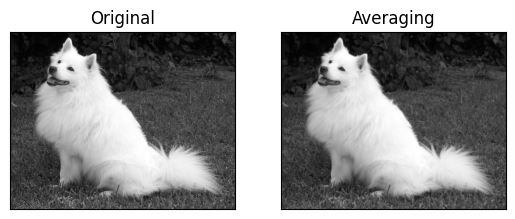

In [9]:
# Solution
img = cv2.imread('/content/ComputerVision26/Praktikum 2/dog_gray.png')
assert img is not None, "file could not be read, check with os.path.exists()"
kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img,-1,kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

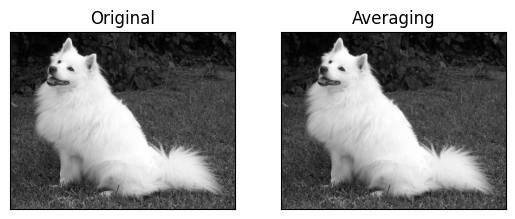

In [10]:
kernel = np.ones((3,3),np.float32)/9
dst = cv2.filter2D(img,-1,kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

The 5x5 Kernel has the stronger blurring effect, because he affects a greater area than the 3x3 Kernel.

## 2. Gaussian filter

**Exercises 2.1 (5 points)**
Given the 2D continuous Gaussian filter formulated as

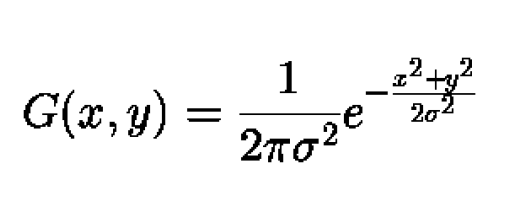

- Write a hand-made function "gauss_kernel(size, sigma)" to compute the discrete/approximated Gaussian kernel in 2D.

- Use this function to compute the Gaussian kernels for (a) kernel size = $5*5$, $\sigma=1$. (b) kernel size=$11*11$, $\sigma=2$

- Use cv2.getGaussianKernel(size, sigma) to get 1D Gaussian kernel.

- Because 2D Gaussian filter is separable, please use cv2.getGaussianKernel() to get 2D Gaussian kernel.

Note:
-  One can use np.mgrid() to discretize the 2D x-y-plane.

-  The sum of all weights of the Gaussian kernel should be equal to 1.

-  Separable filter: https://en.wikipedia.org/wiki/Separable_filter




In [11]:
import numpy as np

def gauss_kernel(size, sigma):
  # Determine the center of the kernel
  center = size // 2

  # Create coordinate system for the 2D kernel
  # x and y will be 2D arrays, each representing the coordinates
  # For a size 5 kernel, coordinates range from -2 to 2
  x, y = np.mgrid[-center : center + 1, -center : center + 1]

  # Apply the 2D Gaussian formula
  # G(x, y) = (1 / (2 * pi * sigma^2)) * e^(-(x^2 + y^2) / (2 * sigma^2))
  # The (1 / (2 * pi * sigma^2)) part is absorbed into normalization later
  kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))

  # Normalize the kernel so that its sum is 1
  kernel /= kernel.sum()

  return kernel

In [12]:
# (a) Using custom gauss_kernel for size = 5, sigma = 1
kernel_5x5_s1 = gauss_kernel(size=5, sigma=1)
print("Custom 5x5 Gaussian Kernel (sigma=1):\n", kernel_5x5_s1)
print("Sum of custom 5x5 kernel elements: ", np.sum(kernel_5x5_s1))

# (b) Using custom gauss_kernel for size = 11, sigma = 2
kernel_11x11_s2 = gauss_kernel(size=11, sigma=2)
print("\nCustom 11x11 Gaussian Kernel (sigma=2):\n", kernel_11x11_s2)
print("Sum of custom 11x11 kernel elements: ", np.sum(kernel_11x11_s2))

Custom 5x5 Gaussian Kernel (sigma=1):
 [[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]
Sum of custom 5x5 kernel elements:  1.0

Custom 11x11 Gaussian Kernel (sigma=2):
 [[7.76553851e-05 2.39195426e-04 5.73799997e-04 1.07199952e-03
  1.55975010e-03 1.76742842e-03 1.55975010e-03 1.07199952e-03
  5.73799997e-04 2.39195426e-04 7.76553851e-05]
 [2.39195426e-04 7.36773780e-04 1.76742842e-03 3.30199100e-03
  4.80436855e-03 5.44406279e-03 4.80436855e-03 3.30199100e-03
  1.76742842e-03 7.36773780e-04 2.39195426e-04]
 [5.73799997e-04 1.76742842e-03 4.23984037e-03 7.92106463e-03
  1.15250810e-02 1.30596277e-02 1.15250810e-02 7.92106463e-03
  4.23984037e-03 1.76742842e-03 5.73799997e-04]
 [1.07199952e-03 3.30199100e-03 7.92106463e-03 1.47984970e-02
  2.153168

In [16]:
# Use cv2.getGaussianKernel() to get 1D Gaussian kernel and combine for 2D

# For size 5x5, sigma=1
kernel_x_5_s1 = cv2.getGaussianKernel(ksize=5, sigma=1)
kernel_y_5_s1 = cv2.getGaussianKernel(ksize=5, sigma=1)
kernel_2D_cv2_5x5_s1 = kernel_x_5_s1 * kernel_y_5_s1.T
print("\nOpenCV 2D Gaussian Kernel (5x5, sigma=1) from 1D kernels:\n", kernel_2D_cv2_5x5_s1)
print("Sum of OpenCV 5x5 kernel elements: ", np.sum(kernel_2D_cv2_5x5_s1))

# For size 11x11, sigma=2
kernel_x_11_s2 = cv2.getGaussianKernel(ksize=11, sigma=2)
kernel_y_11_s2 = cv2.getGaussianKernel(ksize=11, sigma=2)
kernel_2D_cv2_11x11_s2 = kernel_x_11_s2 * kernel_y_11_s2.T
print("\nOpenCV 2D Gaussian Kernel (11x11, sigma=2) from 1D kernels:\n", kernel_2D_cv2_11x11_s2)
print("Sum of OpenCV 11x11 kernel elements: ", np.sum(kernel_2D_cv2_11x11_s2))


OpenCV 2D Gaussian Kernel (5x5, sigma=1) from 1D kernels:
 [[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]
Sum of OpenCV 5x5 kernel elements:  1.0

OpenCV 2D Gaussian Kernel (11x11, sigma=2) from 1D kernels:
 [[7.76553851e-05 2.39195426e-04 5.73799997e-04 1.07199952e-03
  1.55975010e-03 1.76742842e-03 1.55975010e-03 1.07199952e-03
  5.73799997e-04 2.39195426e-04 7.76553851e-05]
 [2.39195426e-04 7.36773780e-04 1.76742842e-03 3.30199100e-03
  4.80436855e-03 5.44406279e-03 4.80436855e-03 3.30199100e-03
  1.76742842e-03 7.36773780e-04 2.39195426e-04]
 [5.73799997e-04 1.76742842e-03 4.23984037e-03 7.92106463e-03
  1.15250810e-02 1.30596277e-02 1.15250810e-02 7.92106463e-03
  4.23984037e-03 1.76742842e-03 5.73799997e-04]
 [1.07199952e-03 3.30199100e-03

**Exercise 2.2 (5 points)**
- Load image "**dog_gray.png**"

- apply Gaussian filter function cv2.GaussianBlur() with size (5, 5) and $sigma=1$ to the image. Display the output.

- apply Gaussian filter function cv2.GaussianBlur() with size (11, 11) and $sigma=2$ to the image. Display the output.







Solutions for Gaussian Blur


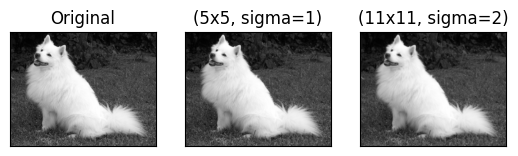

In [25]:
img = cv2.imread('/content/ComputerVision26/Praktikum 2/dog_gray.png')
assert img is not None, "file could not be read, check with os.path.exists()"

# Apply Gaussian filter with size (5, 5) and sigma=1
print("Solutions for Gaussian Blur")
dst_5x5_s1 = cv2.GaussianBlur(img, (5, 5), 1)
plt.subplot(131),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(dst_5x5_s1),plt.title('(5x5, sigma=1)')
plt.xticks([]), plt.yticks([])

# Apply Gaussian filter with size (11, 11) and sigma=2
dst_11x11_s2 = cv2.GaussianBlur(img, (11, 11), 2)
plt.subplot(133),plt.imshow(dst_11x11_s2),plt.title('(11x11, sigma=2)')
plt.xticks([]), plt.yticks([])
plt.show()

## 3. Convolution & Correlation

**Exercise 3.1 (5 points)**
- Run this code to compute the convolution: re_full = np.convolve([1, 2, 3], [0, 1, 0.5], mode='full')
- Compute re_full by yourself. For example, re_full[0] = 1*? + ?*? + ?*? + ..... , re_full[1] = ....

- Run this code to compute the convolution: re_valid = np.convolve([1, 2, 3], [0, 1, 0.5], mode='valid')
- Compute re_valid by yourself, i.e. re_valid = ?*? + ?*? + ...

Note: Please write down the calculation explicitly so that it is understood how the results are computed.

In [ ]:
# Solution for Exercise 3.1

# Define the input arrays
a = [1, 2, 3]
k = [0, 1, 0.5]

# Compute convolution with mode='full'
re_full = np.convolve(a, k, mode='full')
print("Convolution (mode='full'):", re_full)

# Compute convolution with mode='valid'
re_valid = np.convolve(a, k, mode='valid')
print("Convolution (mode='valid'):", re_valid)

**Exercise 3.2 (5 points)**
- Run this code to compute the correlation: re_full = np.correlate([2, 5, 6], [1, 4, 6, 7], mode='full')
- Compute re_full by yourself. For example, re_full[0] = 1*? + ?? + ?? + ..... , re_full[1] = ....
- Run this code to compute the correlation: re_valid = np.correlate([2, 5, 6], [1, 4, 6, 7], mode='valid')
- Compute re_valid by yourself, i.e. re_valid = ?*? + ?*? + ...

In [ ]:
# solution


**Exercise 3.3 (5 points)**
- For a = [0, 1, 2, 3, 4, 5], formulate any non-trivial 1D kernel k with length=5, so that $conv(a, k) = korr(a, k)$. Check the equality using numpy.

- Explain under which condition of k we can have $conv(a, k) = korr(a, k)$?

In [ ]:
# solution


**Text fett markieren**# 4. High-pass filter

**Exercise 4.1 (5 points)**: Prewitt filter

- Load image "**rectangular.png**" as a gray-scale image using OpenCV.
- Select one of Prewitt filters to detect the upper and lower edge of the rectangular.
- Display the detected edges.

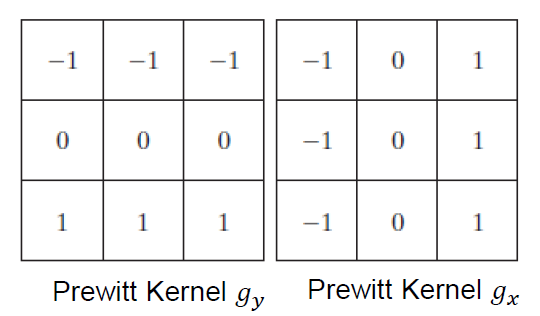

Note that if you get only a single edge, please understand first why the other edge is missing.

In [ ]:
# solution

**Exercise 4.2 (5 points)**: Unsharp masking
- Write a function to do "unsharp masking" to a given image. Note that one can use any blurring kernel.
- Load image "**hso_gray.png**" and call this function to get the sharpened image.
- Select proper parameters.  Display the mask and the resulted image.

In [ ]:
# solution

